# Limpieza de datos para predecir `RainTomorrow`


## Resumen del proceso

 El proceso incluye:

- eliminación de columnas problemáticas: `Sunshine`, `Evaporation`, `Cloud3pm` y `Cloud9am` por alto porcentaje de nulos, y `RISK_MM` por fuga de información,
- transformación de `RainTomorrow` a variable binaria,
- creación de variables temporales desde `Date`,
- imputación de valores nulos en variables numéricas y categóricas,
- codificación de variables categóricas mediante One-Hot Encoding,
- partición estratificada en conjuntos de entrenamiento y prueba,
- entrenamiento de un árbol de decisión sin SMOTE,
- entrenamiento de un segundo árbol de decisión aplicando SMOTE solo sobre el conjunto de entrenamiento,
- evaluación de ambos modelos con `Accuracy`, `Precision_Yes`, `Recall_Yes`, `F1_Yes` y matriz de confusión,
- comparación final para identificar qué modelo predice mejor la clase `Yes`, es decir, los días en que sí lloverá.



In [1]:
# Importamos las librerías que usaremos para cargar, limpiar, entrenar y evaluar el modelo.
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier


In [2]:
# Definimos la fuente de datos, la variable objetivo y las columnas problemáticas.
DATA_URL = "https://raw.githubusercontent.com/Darygarav/base-de-datos-australia/main/weatherAUS.csv"
LOCAL_DATASET = Path("weatherAUS.csv")

LEAKAGE_COLUMNS = ["RISK_MM"]

# Esta función intenta cargar primero un archivo local y, si no existe, usa la URL.
def load_weather_data(url: str = DATA_URL) -> pd.DataFrame:
    if LOCAL_DATASET.exists():
        return pd.read_csv(LOCAL_DATASET)
    return pd.read_csv(url)

# Cargamos el dataset original para revisar su tamaño y primeras filas.
df = load_weather_data()
print(f"Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}")
display(df.head())


Filas: 142,193 | Columnas: 24


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,0.0,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,0.0,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,0.0,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,1.0,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,0.2,No


In [3]:
# Calculamos cuántos valores faltantes tiene cada variable.
# Esto nos ayuda a decidir qué columnas conviene eliminar o imputar.
missing = pd.DataFrame({
    "nulos": df.isna().sum(),
    "porcentaje": (df.isna().sum() / len(df) * 100).round(2)
}).sort_values("porcentaje", ascending=False)

print("Variables con nulos:")
missing_con_nulos = missing[missing["nulos"] > 0].copy()
missing_con_nulos.insert(0, "orden", range(1, len(missing_con_nulos) + 1))
display(missing_con_nulos)


Variables con nulos:


,orden,nulos,porcentaje
Sunshine,1,67816,47.69
Evaporation,2,60843,42.79
Cloud3pm,3,57094,40.15
Cloud9am,4,53657,37.74
Pressure9am,5,14014,9.86
Pressure3pm,6,13981,9.83
WindDir9am,7,10013,7.04
WindGustDir,8,9330,6.56
WindGustSpeed,9,9270,6.52
WindDir3pm,10,3778,2.66


In [4]:
# Esta función aplica la limpieza principal para predecir RainTomorrow.
def clean_weather_data(df: pd.DataFrame):
    # Trabajamos sobre una copia para no modificar el dataset original.
    data = df.copy()

    # Convertimos Date a formato fecha y extraemos variables temporales útiles.
    data["Date"] = pd.to_datetime(data["Date"], errors="coerce")
    data["Year"] = data["Date"].dt.year
    data["Month"] = data["Date"].dt.month
    data["Day"] = data["Date"].dt.day
    data = data.drop(columns=["Date"])

    # Eliminamos columnas con demasiados nulos y una columna con fuga de información.
    HIGH_MISSING_COLUMNS = ["Sunshine", "Evaporation", "Cloud3pm", "Cloud9am"]
    drop_columns = [col for col in HIGH_MISSING_COLUMNS + LEAKAGE_COLUMNS if col in data.columns]
    data = data.drop(columns=drop_columns)

    # Nos aseguramos de que la variable objetivo exista y la convertimos a 0 y 1.
    TARGET = "RainTomorrow"
    data = data[data[TARGET].notna()].copy()
    data[TARGET] = data[TARGET].map({"No": 0, "Yes": 1})#convierte en binario y NaN
    data = data[data[TARGET].notna()].copy()
    data[TARGET] = data[TARGET].astype(int)

    # Separamos variables predictoras y variable objetivo.
    X = data.drop(columns=[TARGET])
    y = data[TARGET]
    return X, y, data

# Ejecutamos la limpieza y revisamos el resultado.
X, y, clean_df = clean_weather_data(df)

print(f"Dataset limpio: {clean_df.shape[0]:,} filas y {clean_df.shape[1]} columnas")
print(f"Variables predictoras: {X.shape[1]}")
print("Distribución de la variable objetivo:")
display(y.value_counts().rename(index={0: "No", 1: "Yes"}))
display(clean_df.head())


Dataset limpio: 142,193 filas y 21 columnas
Variables predictoras: 20
Distribución de la variable objetivo:


RainTomorrow
No     110316
Yes     31877
Name: count, dtype: int64

,Location,MinTemp,MaxTemp,Rainfall,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,...,Humidity3pm,Pressure9am,Pressure3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Year,Month,Day
0,Albury,13.4,22.9,0.6,W,44.0,W,WNW,20.0,24.0,...,22.0,1007.7,1007.1,16.9,21.8,No,0,2008,12,1
1,Albury,7.4,25.1,0.0,WNW,44.0,NNW,WSW,4.0,22.0,...,25.0,1010.6,1007.8,17.2,24.3,No,0,2008,12,2
2,Albury,12.9,25.7,0.0,WSW,46.0,W,WSW,19.0,26.0,...,30.0,1007.6,1008.7,21.0,23.2,No,0,2008,12,3
3,Albury,9.2,28.0,0.0,NE,24.0,SE,E,11.0,9.0,...,16.0,1017.6,1012.8,18.1,26.5,No,0,2008,12,4
4,Albury,17.5,32.3,1.0,W,41.0,ENE,NW,7.0,20.0,...,33.0,1010.8,1006.0,17.8,29.7,No,0,2008,12,5


## Justificacion 

1. Sunshine, Evaporation, Cloud3pm, Cloud9am (muchas nulas)
En tu propio análisis del dataset esas variables suelen tener muchísimos nulos (del orden de 40–48 % de las filas). En ese escenario:

- Imputar (mediana, media, etc.) significa inventar un valor para casi la mitad de los registros en esa variable. El modelo puede aprender patrones poco fiables o ruido que en realidad son el método de relleno, no el fenómeno meteorológico.

- Además, con tantos faltantes, la columna aporta poca información real y puede empeorar o inestabilizar el entrenamiento frente a columnas más completas.

Por eso es razonable eliminarlas: prefieres perder esa señal a cargar con demasiada incertidumbre imputada.

In [5]:
# Identificamos qué columnas son numéricas y cuáles son categóricas.
numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "string"]).columns.tolist()

# Para variables numéricas imputamos con la mediana, porque resiste mejor los outliers.
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])

# Para variables categóricas imputamos con la moda y luego hacemos One-Hot Encoding.
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])

# Unimos ambos tratamientos en un solo preprocesador.
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features),
])

print("Variables numéricas:", len(numeric_features))
print("Variables categóricas:", len(categorical_features))
print("Columnas numéricas:", numeric_features)
print("Columnas categóricas:", categorical_features)


Variables numéricas: 15
Variables categóricas: 5
Columnas numéricas: ['MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm', 'Year', 'Month', 'Day']
Columnas categóricas: ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']


## JUSTICACION

Rellena los huecos (NaN) en cada columna numérica con la mediana de esa misma columna calculada solo con los valores que sí existen.

Se usa la mediana y no, por ejemplo, la media, sobre todo por esto:

Robustez ante valores atípicos
La media se mueve mucho si hay unas pocas filas con valores muy altos o muy bajos. La mediana es el “valor del medio” al ordenar los datos, así que cambios extremos en pocas observaciones casi no la mueven.

Datos sesgados
En meteorología (temperaturas, lluvia, viento, etc.) muchas variables no son simétricas. La mediana suele ser una mejor referencia de “valor típico” que la media para sustituir faltantes de forma conservadora.

Es una regla simple y estable
No asume un modelo dentro del imputador: solo un estadístico por columna, fácil de interpretar y de aplicar en un pipeline.

Imputamos las variables categóricas con la moda porque es la forma más simple y consistente de rellenar valores faltantes cuando trabajamos con categorías como Location, WindGustDir o RainToday. La moda reemplaza el nulo por la categoría más frecuente, lo que permite no perder filas y mantener un valor válido dentro del conjunto original. En tu caso esto tiene sentido porque varias variables categóricas tienen pocos nulos en comparación con el tamaño total del dataset, así que usar la categoría más común introduce menos distorsión que eliminar registros completos. Además, como Decision Tree no necesita supuestos de normalidad ni relaciones lineales, tolera bastante bien este tipo de imputación.

Elegimos One-Hot Encoding porque tus variables categóricas son principalmente nominales, es decir, categorías sin un orden natural. Por ejemplo, WindDir9am o Location no tienen jerarquía entre sus valores. One-Hot crea una columna binaria por categoría y evita inventar relaciones numéricas falsas. Si en vez de eso usaras algo como Label Encoding, el modelo podría interpretar erróneamente que una categoría “vale más” que otra solo por el número asignado, por ejemplo pensar que N = 1 y S = 4 implica distancia u orden, lo que no tiene sentido meteorológico.

In [6]:
# Dividimos los datos en entrenamiento y prueba manteniendo la proporción de clases.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

# Creamos un pipeline que primero limpia los datos y luego entrena el árbol de decisión.
decision_tree_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        max_depth=15,
        min_samples_split=10,
        min_samples_leaf=4,
        class_weight="balanced",
        random_state=42,
        criterion = "entropy"
    )),
])

# Mostramos las dimensiones finales para confirmar que todo quedó listo.
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")
print("Pipeline listo para entrenar.")


X_train: (113754, 20)
X_test: (28439, 20)
y_train: (113754,)
y_test: (28439,)
Pipeline listo para entrenar.


## Justificación de los parámetros del árbol de decisión

Para ambos modelos se utilizan los mismos hiperparámetros, de modo que la comparación entre el árbol sin SMOTE y el árbol con SMOTE sea justa. La única diferencia entre ambos modelos es la aplicación de SMOTE sobre el conjunto de entrenamiento.

- `max_depth=15`: limita la profundidad máxima del árbol para evitar que crezca demasiado y se sobreajuste a los datos de entrenamiento.
- `min_samples_split=10`: exige al menos 10 observaciones para dividir un nodo, lo que ayuda a evitar reglas demasiado específicas.
- `min_samples_leaf=4`: obliga a que cada hoja tenga al menos 4 observaciones, reduciendo la posibilidad de crear hojas basadas en muy pocos casos.
- `class_weight="balanced"`: ajusta el peso de las clases para compensar el desbalance de `RainTomorrow`, dando mayor importancia a la clase minoritaria `Yes`.
- `random_state=42`: fija la semilla aleatoria para que los resultados sean reproducibles.
- `criterion="entropy"`: utiliza la ganancia de información para decidir las divisiones del árbol, buscando separar los datos en grupos más puros respecto a la variable objetivo.


## Entrenamiento y evaluación

A partir de aquí ajustamos el árbol de decisión y medimos su desempeño sobre el conjunto de prueba.

Dado que existen pares de variables numéricas con correlaciones muy altas, es razonable evaluar la eliminación de algunas de ellas para reducir redundancia y simplificar el modelo. Sin embargo, al trabajar con árboles de decisión, esta reducción no es estrictamente necesaria, ya que este tipo de algoritmo es menos sensible a la multicolinealidad que los modelos lineales.

In [7]:
# Entrenamos el pipeline completo usando los datos de entrenamiento.
decision_tree_pipeline.fit(X_train, y_train)

# Generamos predicciones sobre el conjunto de prueba para evaluar el modelo.
y_pred = decision_tree_pipeline.predict(X_test)

print("Modelo entrenado correctamente.")


Modelo entrenado correctamente.


In [8]:
# Calculamos las métricas principales para clasificación binaria.
# Precision, recall y F1-score se calculan sobre la clase positiva: Yes.
base_metrics = {
    "Modelo": "Decision Tree sin SMOTE",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision_Yes": precision_score(y_test, y_pred),
    "Recall_Yes": recall_score(y_test, y_pred),
    "F1_Yes": f1_score(y_test, y_pred),
}

metrics_df = pd.DataFrame([base_metrics]).melt(
    id_vars="Modelo",
    var_name="Métrica",
    value_name="Valor",
)

display(metrics_df.style.format({"Valor": "{:.4f}"}))

print("Reporte de clasificación - Decision Tree sin SMOTE:")
print(classification_report(y_test, y_pred, target_names=["No", "Yes"]))


,Modelo,Métrica,Valor
0,Decision Tree sin SMOTE,Accuracy,0.7699
1,Decision Tree sin SMOTE,Precision_Yes,0.4907
2,Decision Tree sin SMOTE,Recall_Yes,0.6976
3,Decision Tree sin SMOTE,F1_Yes,0.5761


Reporte de clasificación - Decision Tree sin SMOTE:
              precision    recall  f1-score   support

          No       0.90      0.79      0.84     22064
         Yes       0.49      0.70      0.58      6375

    accuracy                           0.77     28439
   macro avg       0.70      0.74      0.71     28439
weighted avg       0.81      0.77      0.78     28439



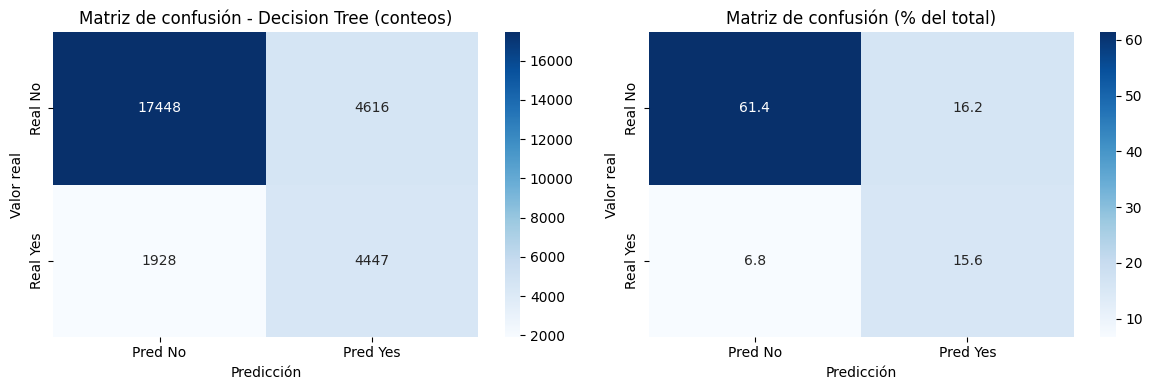

In [9]:
# Construimos la matriz de confusión para ver aciertos y errores por clase.
cm = confusion_matrix(y_test, y_pred)
# Porcentaje respecto al total de predicciones (los cuatro recuadros suman 100 %).
cm_pct = cm.astype(float) / cm.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0],
    xticklabels=["Pred No", "Pred Yes"],
    yticklabels=["Real No", "Real Yes"],
)
axes[0].set_title("Matriz de confusión - Decision Tree (conteos)")
axes[0].set_xlabel("Predicción")
axes[0].set_ylabel("Valor real")

sns.heatmap(
    cm_pct,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    ax=axes[1],
    xticklabels=["Pred No", "Pred Yes"],
    yticklabels=["Real No", "Real Yes"],
)
axes[1].set_title("Matriz de confusión (% del total)")
axes[1].set_xlabel("Predicción")
axes[1].set_ylabel("Valor real")

plt.tight_layout()
plt.show()


## Modelo con SMOTE

Ahora entrenamos un segundo árbol de decisión aplicando SMOTE solo sobre el conjunto de entrenamiento. Esto evita que el conjunto de prueba se contamine con datos sintéticos y mantiene una evaluación realista.

In [10]:
# Creamos un segundo pipeline: primero preprocesa, luego aplica SMOTE y finalmente entrena el árbol.
decision_tree_smote_pipeline = ImbPipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", DecisionTreeClassifier(
        max_depth=15,
        min_samples_split=10,
        min_samples_leaf=4,
        class_weight="balanced",
        random_state=42,
        criterion = "entropy"
    )),
])

# Entrenamos el modelo con SMOTE usando solo los datos de entrenamiento.
decision_tree_smote_pipeline.fit(X_train, y_train)

# Generamos predicciones sobre el mismo conjunto de prueba usado por el modelo sin SMOTE.
y_pred_smote = decision_tree_smote_pipeline.predict(X_test)

print("Modelo con SMOTE entrenado correctamente.")


Modelo con SMOTE entrenado correctamente.


SMOTE se utiliza para tratar el desbalance de la variable objetivo RainTomorrow. Aunque el desbalance se identifica en la columna objetivo, la técnica genera nuevas observaciones sintéticas en el espacio de las variables predictoras para aumentar la representación de la clase minoritaria (Yes). Este procedimiento debe aplicarse únicamente sobre el conjunto de entrenamiento para evitar fuga de información hacia el conjunto de prueba.

In [11]:
# Calculamos las mismas métricas para poder comparar ambos modelos.
smote_metrics = {
    "Modelo": "Decision Tree con SMOTE",
    "Accuracy": accuracy_score(y_test, y_pred_smote),
    "Precision_Yes": precision_score(y_test, y_pred_smote),
    "Recall_Yes": recall_score(y_test, y_pred_smote),
    "F1_Yes": f1_score(y_test, y_pred_smote),
}

smote_metrics_df = pd.DataFrame([smote_metrics]).melt(
    id_vars="Modelo",
    var_name="Métrica",
    value_name="Valor",
)

display(smote_metrics_df.style.format({"Valor": "{:.4f}"}))

print("Reporte de clasificación - Decision Tree con SMOTE:")
print(classification_report(y_test, y_pred_smote, target_names=["No", "Yes"]))


,Modelo,Métrica,Valor
0,Decision Tree con SMOTE,Accuracy,0.8214
1,Decision Tree con SMOTE,Precision_Yes,0.6015
2,Decision Tree con SMOTE,Recall_Yes,0.6025
3,Decision Tree con SMOTE,F1_Yes,0.6020


Reporte de clasificación - Decision Tree con SMOTE:
              precision    recall  f1-score   support

          No       0.89      0.88      0.88     22064
         Yes       0.60      0.60      0.60      6375

    accuracy                           0.82     28439
   macro avg       0.74      0.74      0.74     28439
weighted avg       0.82      0.82      0.82     28439



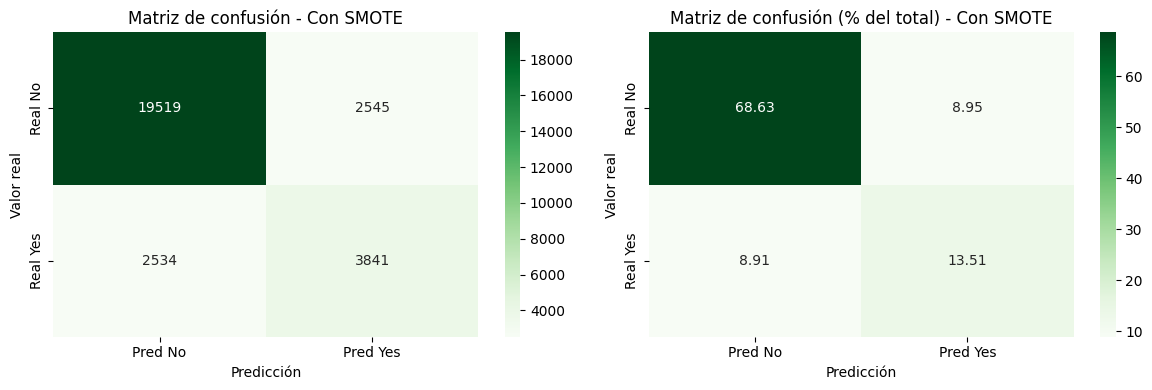

In [12]:
# Matriz de confusión del modelo con SMOTE.
cm_smote = confusion_matrix(y_test, y_pred_smote)
cm_smote_pct = cm_smote / cm_smote.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(
    cm_smote,
    annot=True,
    fmt="d",
    cmap="Greens",
    ax=axes[0],
    xticklabels=["Pred No", "Pred Yes"],
    yticklabels=["Real No", "Real Yes"],
)
axes[0].set_title("Matriz de confusión - Con SMOTE")
axes[0].set_xlabel("Predicción")
axes[0].set_ylabel("Valor real")

sns.heatmap(
    cm_smote_pct,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    ax=axes[1],
    xticklabels=["Pred No", "Pred Yes"],
    yticklabels=["Real No", "Real Yes"],
)
axes[1].set_title("Matriz de confusión (% del total) - Con SMOTE")
axes[1].set_xlabel("Predicción")
axes[1].set_ylabel("Valor real")

plt.tight_layout()
plt.show()


## Comparación de modelos

In [14]:
# Unimos las métricas de ambos modelos en una tabla comparativa.
comparison_df = pd.DataFrame([base_metrics, smote_metrics])

display(comparison_df.style.format({
    "Accuracy": "{:.4f}",
    "Precision_Yes": "{:.4f}",
    "Recall_Yes": "{:.4f}",
    "F1_Yes": "{:.4f}",
}))

# Identificamos qué modelo tiene mejor precisión para la clase Yes.
best_precision_model = comparison_df.loc[comparison_df["Precision_Yes"].idxmax(), "Modelo"]
best_f1_model = comparison_df.loc[comparison_df["F1_Yes"].idxmax(), "Modelo"]


,Modelo,Accuracy,Precision_Yes,Recall_Yes,F1_Yes
0,Decision Tree sin SMOTE,0.7699,0.4907,0.6976,0.5761
1,Decision Tree con SMOTE,0.8214,0.6015,0.6025,0.6020


## Conclusión del modelo

En este trabajo se construyó un modelo supervisado para predecir la variable `RainTomorrow`, es decir, si lloverá o no al día siguiente. Para preparar los datos se eliminaron variables problemáticas como `RISK_MM`, debido a que representa fuga de información, y columnas con alto porcentaje de valores faltantes. Además, se transformó la variable `Date`, se imputaron valores nulos, se codificaron variables categóricas mediante One-Hot Encoding y se dividieron los datos en entrenamiento y prueba manteniendo la proporción de clases.

Como la variable objetivo presenta desbalance, se compararon dos modelos de árbol de decisión: uno sin SMOTE y otro aplicando SMOTE sobre el conjunto de entrenamiento. El modelo sin SMOTE obtuvo un `Recall_Yes` más alto, con un valor de 0.6976, lo que significa que detecta una mayor proporción de los días en que realmente llueve. Sin embargo, su `Precision_Yes` fue menor, con 0.4907, lo que indica que genera más falsos positivos.

El modelo con SMOTE obtuvo mejores resultados generales: aumentó el `Accuracy` de 0.7699 a 0.8214, mejoró la `Precision_Yes` de 0.4907 a 0.6015 y también aumentó el `F1_Yes` de 0.5761 a 0.6020. Esto muestra que SMOTE ayudó al modelo a ser más preciso al predecir la clase `Yes`, reduciendo los falsos positivos. No obstante, su `Recall_Yes` bajó a 0.6025, por lo que detecta menos casos reales de lluvia que el modelo sin SMOTE.

En conclusión, si el objetivo principal es predecir con mayor precisión cuándo lloverá, el modelo con SMOTE es más conveniente, ya que presenta mejor precisión y mejor F1-score para la clase `Yes`. Sin embargo, si el objetivo fuera detectar la mayor cantidad posible de días lluviosos, aunque se generen más falsas alarmas, el modelo sin SMOTE podría ser preferible debido a su mayor recall.

Para mejorar el modelo en futuras etapas, se podrían probar técnicas como ajuste de hiperparámetros con GridSearchCV, validación cruzada, modificación del umbral de decisión, selección de variables altamente correlacionadas, uso de SMOTENC para tratar mejor variables categóricas, o modelos más robustos como Random Forest, Gradient Boosting o XGBoost. También sería recomendable evaluar el modelo con curvas Precision-Recall, ya que el problema presenta una clase objetivo desbalanceada.